[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Bigdata-com/bigdata-cookbook/blob/main/API_Tutorials/CoMentions_API/Podcast_most_discussed_companies.ipynb)

# Podcast Pulse: Most Discussed Companies on [Bigdata.com](https://bigdata.com)

This notebook demonstrates how to use the [Co-mentions API](https://docs.bigdata.com/api-reference/search/get-co-mentions) to rank **which companies are most discussed in podcasts** over a rolling time window.

**What this demonstrates**
- Filter the corpus to the **podcasts** content category
- Screen a large company universe (`US_500.csv`) in **batches of 50 entity IDs** per API call
- Accumulate and rank companies by **volume** across all batches
- Present a client-ready leaderboard with ticker, sector, and geography

**Demo window:** last 24 hours (adjustable below).

## Setup

Install dependencies and configure your API key before running:

```bash
cd API_Tutorials/CoMentions_API
uv pip install -r requirements.txt
cp .env.example .env   # add BIGDATA_API_KEY
```

In [1]:
from __future__ import annotations

import os
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Any

import pandas as pd
import plotly.express as px
import requests
from dotenv import load_dotenv

In [2]:
load_dotenv()

API_BASE_URL = os.getenv("BIGDATA_API_BASE_URL", "https://api.bigdata.com")
API_KEY = os.getenv("BIGDATA_API_KEY")
if not API_KEY:
    raise ValueError("Set BIGDATA_API_KEY in .env")

COMENTIONS_ENDPOINT = f"{API_BASE_URL}/v1/search/co-mentions/entities"

session = requests.Session()
session.headers.update({"Content-Type": "application/json", "X-API-KEY": API_KEY})

print("✅ API key configured")

✅ API key configured


## Configuration

| Parameter | Value | Notes |
|-----------|-------|-------|
| `LOOKBACK_HOURS` | 24 | Rolling window ending now (UTC) |
| `BATCH_SIZE` | 50 | Entity IDs per `any_of` filter (API batching) |
| `TOP_N` | 20 | Companies to display after ranking |
| `RESULT_LIMIT` | 100 | Max companies returned per batch call |

The Co-mentions endpoint merges top-by-chunks and top-by-headlines lists. We rank on **`volume`** (chunk-level mention depth) as returned by the API.

In [3]:
LOOKBACK_HOURS = 24
BATCH_SIZE = 50
TOP_N = 20
RESULT_LIMIT = 100

end_dt = datetime.now(timezone.utc)
start_dt = end_dt - timedelta(hours=LOOKBACK_HOURS)
START_TS = start_dt.strftime("%Y-%m-%dT%H:%M:%SZ")
END_TS = end_dt.strftime("%Y-%m-%dT%H:%M:%SZ")

print(f"Window: {START_TS} → {END_TS} ({LOOKBACK_HOURS}h)")

Window: 2026-07-06T14:53:46Z → 2026-07-07T14:53:46Z (24h)


## Load company universe

We use `US_500.csv` — a list of **501** `RP_ENTITY_ID` values representing a broad U.S. large-cap screen. The universe is split into batches of 50 IDs for the `entity.any_of` filter.

In [4]:
UNIVERSE_PATH = Path("US_500.csv")
universe_df = pd.read_csv(UNIVERSE_PATH)
entity_ids: list[str] = universe_df["RP_ENTITY_ID"].astype(str).str.strip().tolist()

batches = [entity_ids[i : i + BATCH_SIZE] for i in range(0, len(entity_ids), BATCH_SIZE)]

print(f"Universe: {len(entity_ids):,} companies")
print(f"Batches: {len(batches)} × up to {BATCH_SIZE} entity IDs")

Universe: 500 companies
Batches: 10 × up to 50 entity IDs


## Query podcast co-mentions in batches

Each request:
1. Restricts documents to the **podcasts** category
2. Requires at least one anchor company from the current batch (`entity.any_of`)
3. Returns only **companies** (`entity_categories`) with full metadata (`entity_details`)

Results from all batches are accumulated and deduplicated by `RP_ENTITY_ID`, keeping the **maximum volume** when a company appears in more than one batch (avoids double-counting across overlapping anchor sets).

In [5]:
def build_comention_body(entity_batch: list[str]) -> dict[str, Any]:
    return {
        "query": {
            "filters": {
                "category": {"mode": "INCLUDE", "values": ["podcasts"]},
                "timestamp": {"start": START_TS, "end": END_TS},
                "entity": {"search_in": "ALL", "any_of": entity_batch},
            },
            "limit": RESULT_LIMIT,
            "entity_details": True,
            "entity_categories": ["companies"],
        }
    }


def fetch_batch_companies(batch_idx: int, entity_batch: list[str]) -> list[dict[str, Any]]:
    body = build_comention_body(entity_batch)
    response = session.post(COMENTIONS_ENDPOINT, json=body)
    response.raise_for_status()
    payload = response.json()
    companies = [
        company
        for company in payload.get("results", {}).get("companies", [])
        if company.get("id") in entity_batch
    ]
    usage = payload.get("usage", {}).get("api_query_units", 0)
    print(
        f"Batch {batch_idx + 1:>2}/{len(batches)} | anchors={len(entity_batch):>2} | "
        f"companies={len(companies):>3} | units={usage}"
    )
    return companies


all_companies: dict[str, dict[str, Any]] = {}

for idx, batch in enumerate(batches):
    for company in fetch_batch_companies(idx, batch):
        entity_id = company.get("id")
        if not entity_id:
            continue

        volume = company.get("volume") or company.get("total_chunks_count") or 0
        headlines = company.get("total_headlines_count") or 0

        if entity_id not in all_companies:
            all_companies[entity_id] = {
                "RP_ENTITY_ID": entity_id,
                "Name": company.get("name", entity_id),
                "ticker": company.get("ticker"),
                "volume": volume,
                "headlines_count": headlines,
                "Sector": company.get("sector"),
                "Country": company.get("country"),
            }
        else:
            existing = all_companies[entity_id]
            existing["volume"] = max(existing["volume"], volume)
            existing["headlines_count"] = max(existing["headlines_count"], headlines)

print(f"\nAccumulated {len(all_companies):,} unique companies across {len(batches)} batches")

Batch  1/10 | anchors=50 | companies= 10 | units=1.0
Batch  2/10 | anchors=50 | companies= 12 | units=1.0
Batch  3/10 | anchors=50 | companies= 12 | units=1.0
Batch  4/10 | anchors=50 | companies= 15 | units=1.0
Batch  5/10 | anchors=50 | companies=  3 | units=1.0
Batch  6/10 | anchors=50 | companies=  9 | units=1.0
Batch  7/10 | anchors=50 | companies= 11 | units=1.0
Batch  8/10 | anchors=50 | companies=  8 | units=1.0
Batch  9/10 | anchors=50 | companies= 11 | units=1.0
Batch 10/10 | anchors=50 | companies=  7 | units=1.0

Accumulated 98 unique companies across 10 batches


## Top companies by podcast volume

Sorted descending on `volume`. Columns: **RP_ENTITY_ID**, **Name**, **ticker**, **volume**, **headlines_count**, **Sector**, **Country**.

In [6]:
results_df = (
    pd.DataFrame(all_companies.values())
    .sort_values("volume", ascending=False)
    .reset_index(drop=True)
)

display_cols = [
  "RP_ENTITY_ID",
  "Name",
  "ticker",
  "volume",
  "Sector",
  "Country",
]

top_companies_df = results_df[display_cols].head(TOP_N).copy()
top_companies_df.index = top_companies_df.index + 1
top_companies_df.index.name = "rank"

top_companies_df

,RP_ENTITY_ID,Name,ticker,volume,Sector,Country
rank,,,,,,
1,D8442A,Apple Inc.,AAPL,156,Technology,US
2,4A6F00,Alphabet Inc.,GOOGL,153,Technology,US
3,12E454,Meta Platforms Inc.,META,123,Technology,US
4,228D42,Microsoft Corp.,MSFT,105,Technology,US
5,ECD263,Netflix Inc.,NFLX,66,Consumer Services,US
6,ACDF88,The Home Depot Inc.,HD,65,Consumer Services,US
7,0157B1,Amazon.com Inc.,AMZN,62,Consumer Services,US
8,E09E2B,NVIDIA Corp.,NVDA,43,Technology,US
9,713810,Walmart Inc.,WMT,39,Consumer Services,US


## Visualization

Horizontal bar chart of the top companies by podcast mention volume.

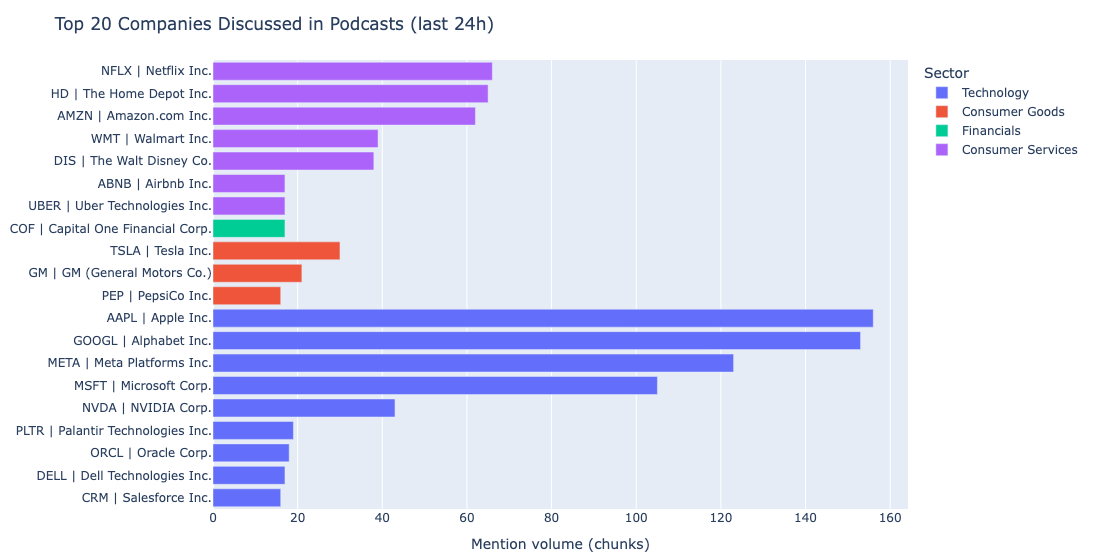

In [7]:
chart_df = top_companies_df.reset_index()
chart_df["label"] = chart_df.apply(
    lambda row: f"{row['ticker'] or '—'} | {row['Name'][:28]}",
    axis=1,
)

fig = px.bar(
    chart_df.sort_values("volume", ascending=True),
    x="volume",
    y="label",
    orientation="h",
    color="Sector",
    title=f"Top {TOP_N} Companies Discussed in Podcasts (last {LOOKBACK_HOURS}h)",
    labels={"volume": "Mention volume (chunks)", "label": "Company"},
    height=max(500, TOP_N * 28),
)
fig.update_layout(yaxis_title=None, margin=dict(l=10, r=10, t=60, b=10))
fig.show()

## Summary & next steps

**API endpoint:** `POST /v1/search/co-mentions/entities`

**Key request fields used:**
- `filters.category` — restrict to `podcasts`
- `filters.entity.any_of` — anchor companies (batched from universe CSV)
- `filters.timestamp` — rolling 24-hour window
- `entity_categories: ["companies"]` — return only company entities
- `entity_details: true` — include name, ticker, sector, country in the response

**Ideas to extend this workflow**
- Change `LOOKBACK_HOURS` or set explicit `START_TS` / `END_TS` for historical windows
- Add a `text` query to narrow podcasts to a theme (e.g. "artificial intelligence earnings")
- Pipe the resulting `RP_ENTITY_ID` list into the Search or Volume API for deeper content retrieval
- Schedule daily runs to track podcast momentum for a thematic basket

Docs: [Co-mentions API reference](https://docs.bigdata.com/api-reference/search/get-co-mentions)